In [8]:
import sys
!{sys.executable} -m pip install matplotlib numpy


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import random

# Função objetivo: f(x) = 2x^2 + 5x
def fitness(x):
    return 2 * (x**2) + 5 * x

# Conversão: Binário -> Real
def bin_para_real(cromossomo):
    inteiro = int("".join(map(str, cromossomo)), 2)
    return -10 + (inteiro / (2**len(cromossomo) - 1)) * 20

# Distância de Hamming Média (Métrica de diversidade)
def calcular_diversidade(populacao):
    distancias = []
    for i in range(len(populacao)):
        for j in range(i + 1, len(populacao)):
            dist = sum(c1 != c2 for c1, c2 in zip(populacao[i], populacao[j]))
            distancias.append(dist)
    return np.mean(distancias) if distancias else 0

In [10]:
def rodar_ag(pop_size=50, chrom_size=10, geracoes=50, taxa_mut=0.01, elitismo_perc=0.0):
    populacao = [[random.randint(0, 1) for _ in range(chrom_size)] for _ in range(pop_size)]
    historico_melhor = []
    historico_medio = []
    historico_div = []

    num_elites = int(pop_size * elitismo_perc)

    for g in range(geracoes):
        # Avaliação
        fit = [fitness(bin_para_real(ind)) for ind in populacao]
        historico_melhor.append(min(fit))
        historico_medio.append(np.mean(fit))
        historico_div.append(calcular_diversidade(populacao))

        # Seleção (Torneio)
        nova_pop = []
        # Elitismo: Mantém os melhores sem alteração
        indices_ordenados = np.argsort(fit)
        for i in range(num_elites):
            nova_pop.append(populacao[indices_ordenados[i]])

        # Crossover e Mutação para o resto
        while len(nova_pop) < pop_size:
            p1, p2 = random.sample(populacao, 2)
            ponto = random.randint(1, chrom_size-1)
            filho = p1[:ponto] + p2[ponto:]
            # Mutação
            filho = [1-bit if random.random() < taxa_mut else bit for bit in filho]
            nova_pop.append(filho)
        
        populacao = nova_pop

    return historico_melhor, historico_medio, historico_div

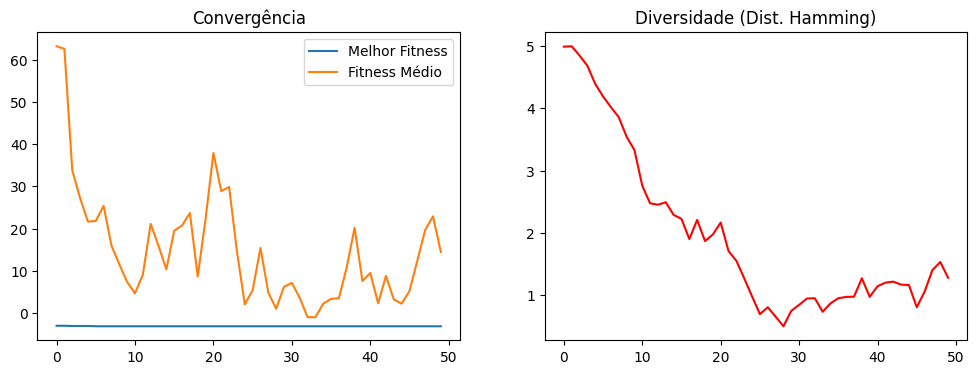

In [11]:
# Exemplo de execução para o Experimento C (20% elitismo)
melhor, medio, div = rodar_ag(elitismo_perc=0.2, taxa_mut=0.02)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(melhor, label='Melhor Fitness')
plt.plot(medio, label='Fitness Médio')
plt.title('Convergência')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(div, color='red')
plt.title('Diversidade (Dist. Hamming)')
plt.show()